## Dog breed classification and pretraine in this chapter.

in this chapter, im going to use various deep learning models, learn about pretraining, and apply them to the project

in this project, i will use pre-trained model that has been trained to classify over 1000 categories, and fine-tune it for dog breed classification.

## summary 

Subject : Dog breed classfication (120+breeds)
Model : ResNet 50
Dataset : Dog breed identification dataset
Task type : Image classification
Evaluation metrics(평가지표) :  Cross-entropy loss,  accuracy

dataset will be obtained from Kaggle 



In [26]:
import sys
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install torch torchvision torchaudio


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/123.0 MB 2.2 MB/s eta 0:00:55
   ---------------------------------------- 1.0/123.0 MB 2.1 MB/s eta 0:00:59
    --------------------------------------- 1.8/123.0 MB 2.5 MB/s eta 0:00:50
    --------------------------------------- 2.4/123.0 MB 2.5 MB/s eta 0:00:49
   - --------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\msm03\Desktop\dog-breed-identification\labels.csv")
display(df.head())

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [13]:
df_count = df.groupby(["breed"])["breed"].count()
df_count = df_count.reset_index(name='count')
df_count = df_count.sort_values(['count'],ascending=False)
display(df_count.head())


,breed,count
97,scottish_deerhound,126
73,maltese_dog,117
1,afghan_hound,116
42,entlebucher,115
11,bernese_mountain_dog,114


max :  126
min :  66
mean :  85.18333333333334
median :  82.0


<Axes: xlabel='breed'>

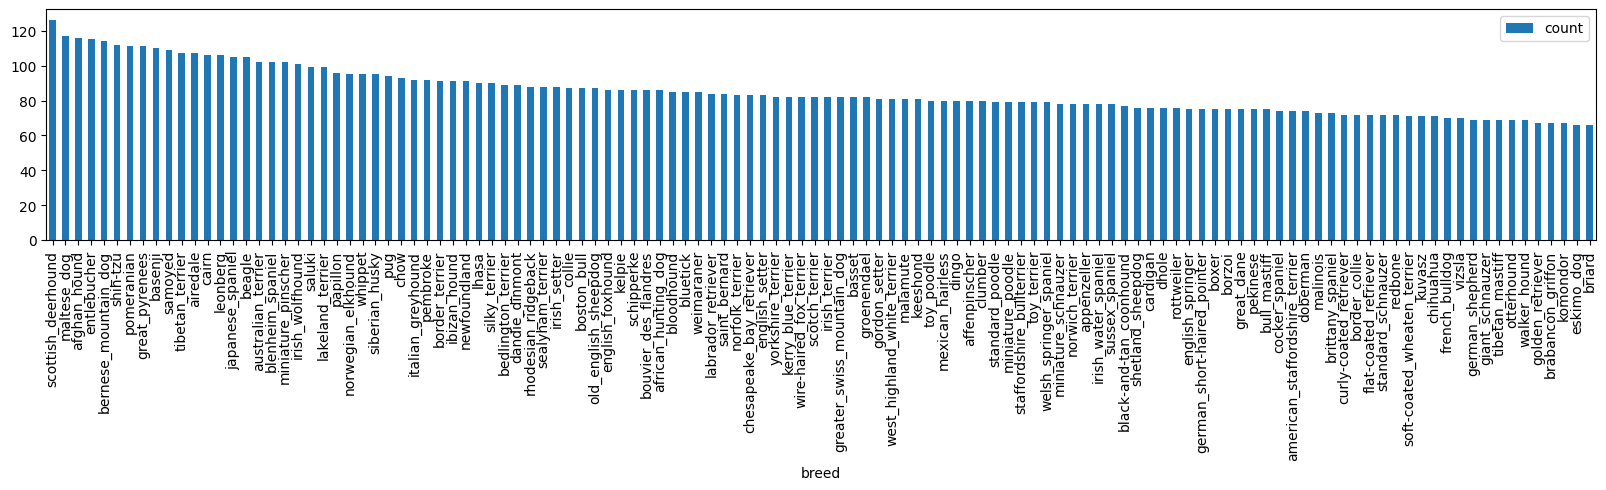

In [21]:
print("max : ",df_count['count'].max())
print("min : ",df_count['count'].min())
print("mean : ",df_count['count'].mean())
print("median : ",df_count['count'].median())

df_count.plot(kind='bar',x='breed',y='count',figsize=(20,3))

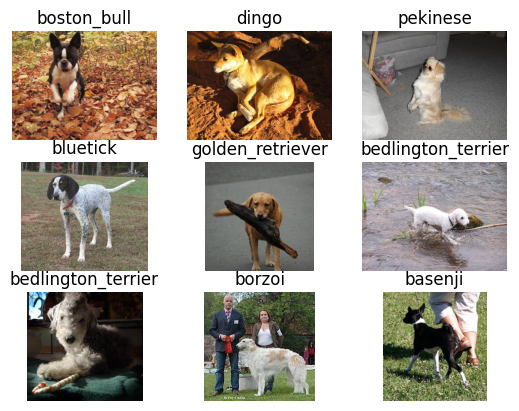

In [22]:
# sample images

from PIL import Image

for i in range(9):
    plt.subplot(3,3,i+1)
    IMAGE_PATH =r"C:\Users\msm03\Desktop\dog-breed-identification\train"
    img = Image.open(f"{IMAGE_PATH}/{df.iloc[i].id}.jpg")

    plt.gca().set_title(df.iloc[i].breed)
    plt.imshow(img)
    plt.axis('off')

## to implement this in Pytorch, define a custom class for loading the dog breed dataset

let's go through it class by class, since it might get too long

In [ ]:
from os.path import join

from PIL import Image
from torch.utils.data import random_split,dataset

class Dogs(dataset.Dataset):
    def __init__(self,root,train=True,transforms=None):
        
        self.train=train
        self.transforms= transforms

        # load image path and labels
        df = pd.read_csv(join(root,'label.csv'))
        self.class_names = df['breed'].unique().tolist()

        if train:
            dir = 'train'
            self.labels=df['breed'].tolist()
        else:
            dir='test'
            df=pd.read_csv(join(root,'sample_submission.csv'))

        self.images = [join(root,dir,f"{id}.jpg") for id in df['id']]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        image = Image.open(self.images[i])
        
        if self.transforms is not None:
            image = self.transforms(image)

        if self.train:
            label=self.class_names.index(self.labels[i])
        else:
            label=-1

        return image,label
